In [1]:
# ============================================================
# AUTOSUPPLY-AI
# NOTEBOOK 10 — DECISION INSIGHTS & VISUALIZATIONS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("=" * 70)
print("AUTOSUPPLY-AI — DECISION INSIGHTS & VISUALIZATIONS")
print("=" * 70)

print("\nLibraries loaded successfully.")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

AUTOSUPPLY-AI — DECISION INSIGHTS & VISUALIZATIONS

Libraries loaded successfully.
Pandas version: 2.3.2
NumPy version: 2.2.2


In [2]:
# ============================================================
# CELL 2 — CHECK AVAILABLE CSV FILES
# ============================================================

from pathlib import Path

NOTEBOOK_DIR = Path.cwd()

print("=" * 70)
print("CHECKING CSV FILES IN NOTEBOOKS FOLDER")
print("=" * 70)

csv_files = sorted(NOTEBOOK_DIR.glob("*.csv"))

if not csv_files:
    print("\nNo CSV files found in:", NOTEBOOK_DIR)
else:
    print(f"\nFound {len(csv_files)} CSV file(s):\n")

    for file in csv_files:
        print(" -", file.name)

print("\nCurrent notebook directory:")
print(NOTEBOOK_DIR)

CHECKING CSV FILES IN NOTEBOOKS FOLDER

Found 12 CSV file(s):

 - autosupply_monthly_forecast.csv
 - autosupply_state_analysis.csv
 - autosupply_state_vehicle_analysis.csv
 - autosupply_vehicle_analysis.csv
 - final_demand_forecast.csv
 - inventory_optimization.csv
 - monthly_demand_forecast.csv
 - state_demand_forecast.csv
 - state_vehicle_demand_forecast.csv
 - state_vehicle_demand_matrix.csv
 - vehicle_group_demand_forecast.csv
 - xgboost_demand_forecast.csv

Current notebook directory:
f:\AutoSupply-AI\notebooks


In [4]:
# ============================================================
# 10. DECISION INSIGHTS
# ============================================================

import pandas as pd
from pathlib import Path

print("=" * 75)
print("AUTOSUPPLY-AI - DECISION INSIGHTS")
print("=" * 75)


# ------------------------------------------------------------
# 1. PROJECT PATH
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

print("\nProject Root:")
print(PROJECT_ROOT)

print("\nNotebook Directory:")
print(NOTEBOOKS_DIR)


# ------------------------------------------------------------
# 2. LOAD EXISTING BUSINESS OUTPUTS
# ------------------------------------------------------------

DEMAND_FILE = NOTEBOOKS_DIR / "final_demand_forecast.csv"
INVENTORY_FILE = NOTEBOOKS_DIR / "inventory_optimization.csv"


print("\n" + "=" * 75)
print("CHECKING REQUIRED FILES")
print("=" * 75)

for file_path in [DEMAND_FILE, INVENTORY_FILE]:

    print(f"\nChecking: {file_path.name}")

    if file_path.exists():
        print("✓ Found")
    else:
        raise FileNotFoundError(
            f"Required file not found:\n{file_path}"
        )


# ------------------------------------------------------------
# 3. LOAD DATA
# ------------------------------------------------------------

demand_df = pd.read_csv(DEMAND_FILE)
inventory_df = pd.read_csv(INVENTORY_FILE)


# ------------------------------------------------------------
# 4. CREATE SUPPLY REQUIREMENT DATA
# ------------------------------------------------------------

# Supply requirement = Forecast demand + Safety stock

inventory_df["supply_requirement"] = (
    inventory_df["total_forecast_demand"]
    + inventory_df["safety_stock"]
)


# Monthly replenishment requirement
inventory_df["monthly_replenishment"] = (
    inventory_df["supply_requirement"]
    / inventory_df["forecast_months"]
)


supply_df = inventory_df.copy()


# ------------------------------------------------------------
# 5. BASIC DATA SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("DECISION INSIGHTS DATA LOADED")
print("=" * 75)

print("\nDemand Forecast:")
print(f"Rows: {len(demand_df):,}")
print(f"Columns: {len(demand_df.columns)}")

print("\nInventory Optimization:")
print(f"Rows: {len(inventory_df):,}")
print(f"Columns: {len(inventory_df.columns)}")

print("\nSupply Planning:")
print(f"Rows: {len(supply_df):,}")
print(f"Columns: {len(supply_df.columns)}")


# ------------------------------------------------------------
# 6. KEY BUSINESS METRICS
# ------------------------------------------------------------

total_forecast_demand = inventory_df["total_forecast_demand"].sum()
total_safety_stock = inventory_df["safety_stock"].sum()
total_supply_requirement = inventory_df["supply_requirement"].sum()
average_monthly_replenishment = inventory_df["monthly_replenishment"].sum()


print("\n" + "=" * 75)
print("KEY SUPPLY CHAIN METRICS")
print("=" * 75)

print(f"\nTotal Forecast Demand:")
print(f"{total_forecast_demand:,.2f}")

print(f"\nTotal Safety Stock:")
print(f"{total_safety_stock:,.2f}")

print(f"\nTotal Supply Requirement:")
print(f"{total_supply_requirement:,.2f}")

print(f"\nAverage Monthly Replenishment Requirement:")
print(f"{average_monthly_replenishment:,.2f}")


# ------------------------------------------------------------
# 7. TOP 10 SUPPLY REQUIREMENTS
# ------------------------------------------------------------

top_supply = (
    supply_df
    .sort_values("supply_requirement", ascending=False)
    .head(10)
)


print("\n" + "=" * 75)
print("TOP 10 SUPPLY REQUIREMENTS")
print("=" * 75)

display(
    top_supply[
        [
            "state",
            "vehicle_group",
            "total_forecast_demand",
            "safety_stock",
            "supply_requirement",
            "monthly_replenishment"
        ]
    ]
)


print("\n" + "=" * 75)
print("DECISION INSIGHTS DATA READY")
print("=" * 75)

AUTOSUPPLY-AI - DECISION INSIGHTS

Project Root:
f:\AutoSupply-AI

Notebook Directory:
f:\AutoSupply-AI\notebooks

CHECKING REQUIRED FILES

Checking: final_demand_forecast.csv
✓ Found

Checking: inventory_optimization.csv
✓ Found

DECISION INSIGHTS DATA LOADED

Demand Forecast:
Rows: 1,218
Columns: 4

Inventory Optimization:
Rows: 203
Columns: 12

Supply Planning:
Rows: 203
Columns: 12

KEY SUPPLY CHAIN METRICS

Total Forecast Demand:
26,760,502.98

Total Safety Stock:
533,275.72

Total Supply Requirement:
27,293,778.70

Average Monthly Replenishment Requirement:
4,548,963.12

TOP 10 SUPPLY REQUIREMENTS


,state,vehicle_group,total_forecast_demand,safety_stock,supply_requirement,monthly_replenishment
0,Rajasthan,Two Wheeler,"9,466,147.50","242,194.66","9,708,342.16","1,618,057.03"
1,Rajasthan,Passenger Vehicle,"2,522,722.25","16,987.44","2,539,709.69","423,284.95"
2,Uttar Pradesh,Two Wheeler,"1,737,674.53","16,524.93","1,754,199.46","292,366.58"
3,Maharashtra,Two Wheeler,"890,074.08","19,191.09","909,265.17","151,544.19"
4,Tamil Nadu,Two Wheeler,"861,641.46","19,242.28","880,883.74","146,813.96"
5,Rajasthan,Three Wheeler,"768,975.80","17,116.60","786,092.40","131,015.40"
6,Karnataka,Two Wheeler,"696,028.61","14,806.87","710,835.48","118,472.58"
7,Bihar,Two Wheeler,"623,129.37","22,696.43","645,825.80","107,637.63"
8,Rajasthan,Goods Vehicle,"581,692.04","14,039.61","595,731.65","99,288.61"
9,Madhya Pradesh,Two Wheeler,"564,443.55","19,306.01","583,749.56","97,291.59"



DECISION INSIGHTS DATA READY


In [5]:
# ============================================================
# 10.1 BUSINESS DECISION SUMMARY
# ============================================================

print("=" * 75)
print("AUTOSUPPLY-AI - BUSINESS DECISION SUMMARY")
print("=" * 75)


# ------------------------------------------------------------
# 1. HIGHEST DEMAND STATE-VEHICLE COMBINATIONS
# ------------------------------------------------------------

top_demand = (
    inventory_df
    .sort_values("total_forecast_demand", ascending=False)
    .head(10)
)

print("\nTOP 10 DEMAND REQUIREMENTS")
print("-" * 75)

display(
    top_demand[
        [
            "state",
            "vehicle_group",
            "total_forecast_demand",
            "safety_stock",
            "supply_requirement"
        ]
    ]
)


# ------------------------------------------------------------
# 2. STATE-LEVEL DEMAND
# ------------------------------------------------------------

state_demand = (
    inventory_df
    .groupby("state", as_index=False)
    .agg(
        total_forecast_demand=("total_forecast_demand", "sum"),
        total_safety_stock=("safety_stock", "sum"),
        total_supply_requirement=("supply_requirement", "sum")
    )
    .sort_values(
        "total_supply_requirement",
        ascending=False
    )
)

print("\nSTATE-LEVEL SUPPLY REQUIREMENT")
print("-" * 75)

display(state_demand.head(10))


# ------------------------------------------------------------
# 3. VEHICLE-GROUP DEMAND
# ------------------------------------------------------------

vehicle_demand = (
    inventory_df
    .groupby("vehicle_group", as_index=False)
    .agg(
        total_forecast_demand=("total_forecast_demand", "sum"),
        total_safety_stock=("safety_stock", "sum"),
        total_supply_requirement=("supply_requirement", "sum")
    )
    .sort_values(
        "total_supply_requirement",
        ascending=False
    )
)

print("\nVEHICLE GROUP SUPPLY REQUIREMENT")
print("-" * 75)

display(vehicle_demand)


# ------------------------------------------------------------
# 4. HIGHEST PRIORITY INVENTORY
# ------------------------------------------------------------

if "inventory_priority" in inventory_df.columns:

    priority_summary = (
        inventory_df["inventory_priority"]
        .value_counts()
        .rename_axis("priority")
        .reset_index(name="count")
    )

    print("\nINVENTORY PRIORITY DISTRIBUTION")
    print("-" * 75)

    display(priority_summary)


# ------------------------------------------------------------
# 5. MANAGEMENT SUMMARY
# ------------------------------------------------------------

highest_state = state_demand.iloc[0]
highest_vehicle = vehicle_demand.iloc[0]
highest_combination = inventory_df.sort_values(
    "supply_requirement",
    ascending=False
).iloc[0]

print("\n" + "=" * 75)
print("MANAGEMENT SUMMARY")
print("=" * 75)

print(
    f"\nHighest supply requirement state: "
    f"{highest_state['state']}"
)

print(
    f"Supply requirement: "
    f"{highest_state['total_supply_requirement']:,.2f}"
)

print(
    f"\nHighest supply requirement vehicle group: "
    f"{highest_vehicle['vehicle_group']}"
)

print(
    f"Supply requirement: "
    f"{highest_vehicle['total_supply_requirement']:,.2f}"
)

print(
    f"\nHighest individual state-vehicle combination: "
    f"{highest_combination['state']} - "
    f"{highest_combination['vehicle_group']}"
)

print(
    f"Supply requirement: "
    f"{highest_combination['supply_requirement']:,.2f}"
)

print("\n" + "=" * 75)
print("BUSINESS DECISION ANALYSIS COMPLETED")
print("=" * 75)

AUTOSUPPLY-AI - BUSINESS DECISION SUMMARY

TOP 10 DEMAND REQUIREMENTS
---------------------------------------------------------------------------


,state,vehicle_group,total_forecast_demand,safety_stock,supply_requirement
0,Rajasthan,Two Wheeler,"9,466,147.50","242,194.66","9,708,342.16"
1,Rajasthan,Passenger Vehicle,"2,522,722.25","16,987.44","2,539,709.69"
2,Uttar Pradesh,Two Wheeler,"1,737,674.53","16,524.93","1,754,199.46"
3,Maharashtra,Two Wheeler,"890,074.08","19,191.09","909,265.17"
4,Tamil Nadu,Two Wheeler,"861,641.46","19,242.28","880,883.74"
5,Rajasthan,Three Wheeler,"768,975.80","17,116.60","786,092.40"
6,Karnataka,Two Wheeler,"696,028.61","14,806.87","710,835.48"
7,Bihar,Two Wheeler,"623,129.37","22,696.43","645,825.80"
8,Rajasthan,Goods Vehicle,"581,692.04","14,039.61","595,731.65"
9,Madhya Pradesh,Two Wheeler,"564,443.55","19,306.01","583,749.56"



STATE-LEVEL SUPPLY REQUIREMENT
---------------------------------------------------------------------------


,state,total_forecast_demand,total_safety_stock,total_supply_requirement
26,Rajasthan,"13,406,245.85","290,745.99","13,696,991.84"
31,Uttar Pradesh,"2,281,127.78","24,126.57","2,305,254.35"
18,Maharashtra,"1,267,945.84","25,625.86","1,293,571.70"
28,Tamil Nadu,"1,082,053.97","23,260.05","1,105,314.02"
14,Karnataka,"949,593.35","20,758.05","970,351.40"
17,Madhya Pradesh,"767,727.89","23,221.16","790,949.05"
4,Bihar,"755,540.35","23,142.73","778,683.08"
9,Gujarat,"738,498.87","16,844.82","755,343.69"
2,Arunachal Pradesh,"607,001.91","12,317.74","619,319.65"
33,West Bengal,"599,764.59","6,250.24","606,014.83"



VEHICLE GROUP SUPPLY REQUIREMENT
---------------------------------------------------------------------------


,vehicle_group,total_forecast_demand,total_safety_stock,total_supply_requirement
5,Two Wheeler,"19,276,446.02","423,626.62","19,700,072.64"
3,Passenger Vehicle,"4,909,632.48","60,668.46","4,970,300.94"
4,Three Wheeler,"1,382,956.89","23,815.99","1,406,772.88"
0,Goods Vehicle,"998,152.57","20,130.24","1,018,282.81"
2,Passenger Transport,"126,595.29","2,709.10","129,304.39"
1,Other Motor Vehicle,"66,719.73","2,325.31","69,045.04"



INVENTORY PRIORITY DISTRIBUTION
---------------------------------------------------------------------------


,priority,count
0,LOW,107
1,MEDIUM,62
2,HIGH,34



MANAGEMENT SUMMARY

Highest supply requirement state: Rajasthan
Supply requirement: 13,696,991.84

Highest supply requirement vehicle group: Two Wheeler
Supply requirement: 19,700,072.64

Highest individual state-vehicle combination: Rajasthan - Two Wheeler
Supply requirement: 9,708,342.16

BUSINESS DECISION ANALYSIS COMPLETED


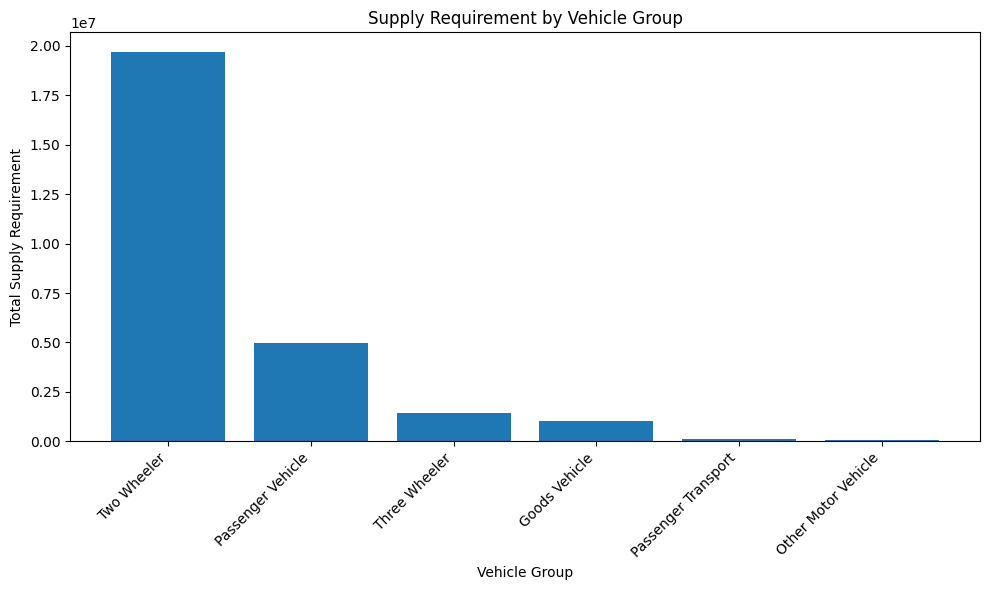

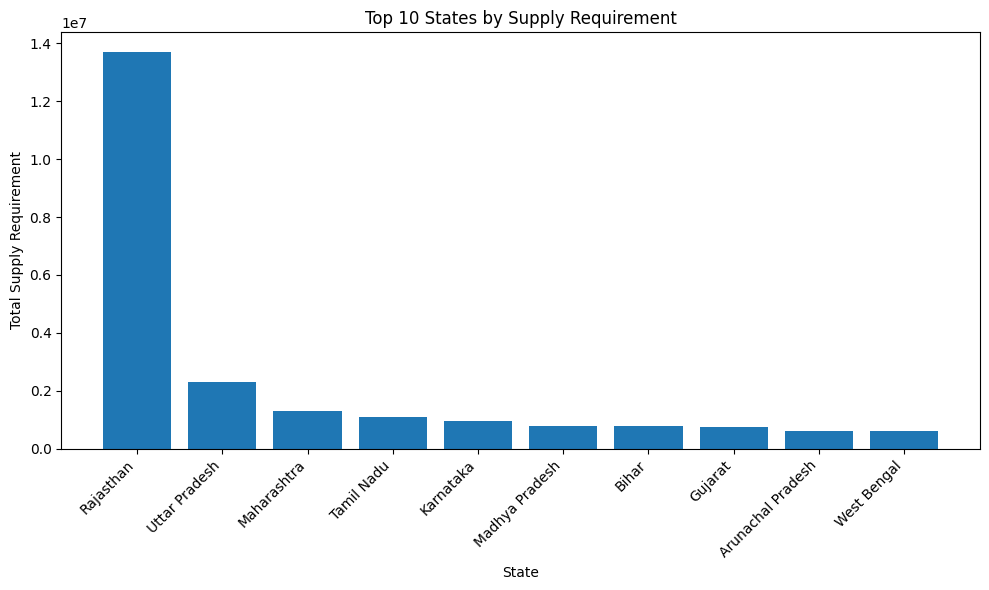

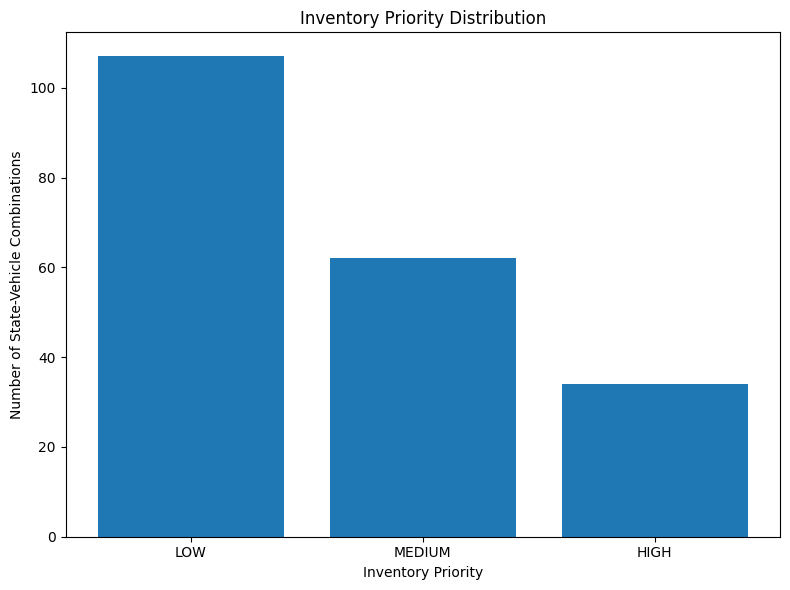

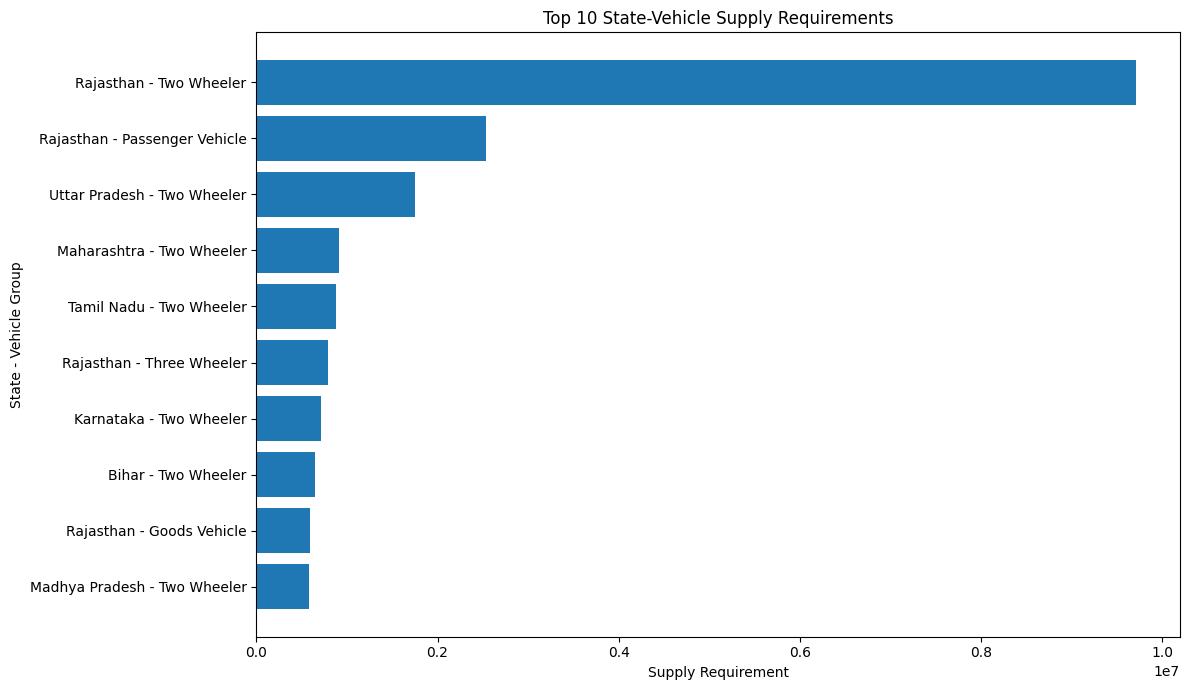

DECISION INSIGHT VISUALIZATIONS COMPLETED


In [6]:
# ============================================================
# 10.2 DECISION INSIGHT VISUALIZATIONS
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. SUPPLY REQUIREMENT BY VEHICLE GROUP
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    vehicle_demand["vehicle_group"],
    vehicle_demand["total_supply_requirement"]
)

plt.title("Supply Requirement by Vehicle Group")
plt.xlabel("Vehicle Group")
plt.ylabel("Total Supply Requirement")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. TOP 10 STATES BY SUPPLY REQUIREMENT
# ------------------------------------------------------------

top_states = state_demand.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_states["state"],
    top_states["total_supply_requirement"]
)

plt.title("Top 10 States by Supply Requirement")
plt.xlabel("State")
plt.ylabel("Total Supply Requirement")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. INVENTORY PRIORITY DISTRIBUTION
# ------------------------------------------------------------

priority_counts = (
    inventory_df["inventory_priority"]
    .value_counts()
)

plt.figure(figsize=(8, 6))

plt.bar(
    priority_counts.index,
    priority_counts.values
)

plt.title("Inventory Priority Distribution")
plt.xlabel("Inventory Priority")
plt.ylabel("Number of State-Vehicle Combinations")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. TOP 10 STATE-VEHICLE COMBINATIONS
# ------------------------------------------------------------

top_combinations = (
    inventory_df
    .sort_values(
        "supply_requirement",
        ascending=False
    )
    .head(10)
    .copy()
)

top_combinations["combination"] = (
    top_combinations["state"]
    + " - "
    + top_combinations["vehicle_group"]
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_combinations["combination"],
    top_combinations["supply_requirement"]
)

plt.title("Top 10 State-Vehicle Supply Requirements")
plt.xlabel("Supply Requirement")
plt.ylabel("State - Vehicle Group")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


print("=" * 75)
print("DECISION INSIGHT VISUALIZATIONS COMPLETED")
print("=" * 75)